In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, accuracy_score, log_loss, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import shap

In [2]:
x_data = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/Anna-Ida/summary.csv')
y_data = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/y_data.csv')

In [3]:
y_data["Datetime"] = pd.to_datetime(
    y_data[["year", "month", "day", "hour", "minute", "second"]]
)

# add datetime to x as well (important!)
x_data["Datetime"] = y_data["Datetime"]

# combine first
df = x_data.copy()
df["target"] = y_data["max_vert_acc"]

# sort once
df = df.sort_values("Datetime").reset_index(drop=True)

# split again
y_df = df["target"]
x_df = df.drop(columns=["target", "Datetime", "source_file"], errors="ignore")

x_train, x_rem, y_train, y_rem = train_test_split(x_df, y_df, test_size=0.2, random_state=42) # 80-10-10 split
x_val, x_test, y_val, y_test = train_test_split(x_rem, y_rem, test_size=0.5, random_state=42)

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(x_train, y_train, eval_set=[( x_val, y_val)], verbose=False)

y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error: {mape}")

Mean Squared Error: 0.007801611284770308
Mean Absolute Percentage Error: 0.3354617046201066


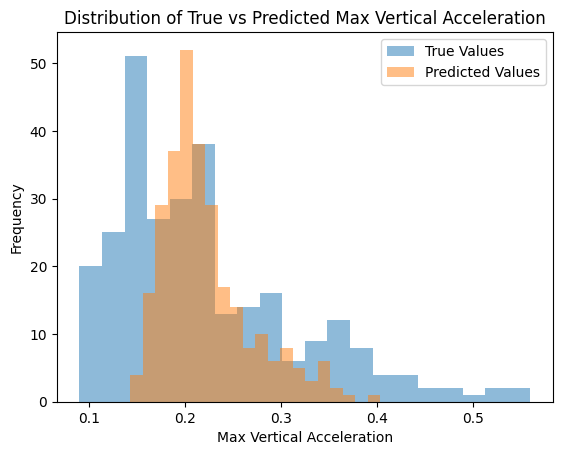

In [4]:
plt.hist(y_test, bins=20, alpha=0.5, label='True Values')
plt.hist(y_pred, bins=20, alpha=0.5, label='Predicted Values')
plt.legend()
plt.xlabel('Max Vertical Acceleration')
plt.ylabel('Frequency')
plt.title('Distribution of True vs Predicted Max Vertical Acceleration')
plt.show()

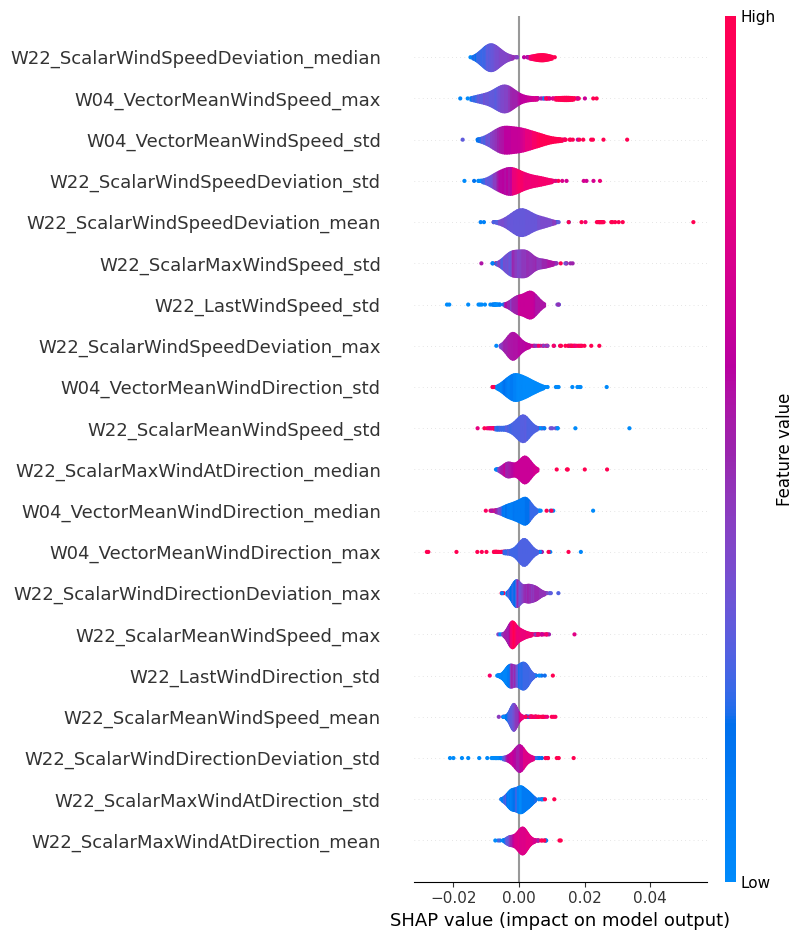

In [5]:
shap_values = shap.TreeExplainer(model).shap_values(x_val)
shap.summary_plot(shap_values, x_val, plot_type="violin")

In [7]:
x_df = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/feature_df.csv')

x_df["Datetime"] = y_data["Datetime"]

# combine first
df = x_df.copy()
df["target"] = y_data["max_vert_acc"]

# sort once
df = df.sort_values("Datetime").reset_index(drop=True)

# split again
y_df = df["target"]
x_df = df.drop(columns=["target", "Datetime", "source_file"], errors="ignore")
train_rem_idx = int(len(x_df) * 0.8) # 80% for training, 20% for validation and testing
val_test_idx = int(len(x_df) * 0.9) # 10% for validation, 10% for testing (from the remaining 20%)

X_train = x_df.iloc[:train_rem_idx]
X_val = x_df.iloc[train_rem_idx:val_test_idx]
X_test = x_df.iloc[val_test_idx:]

y_train = y_df.iloc[:train_rem_idx]
y_val = y_df.iloc[train_rem_idx:val_test_idx]
y_test = y_df.iloc[val_test_idx:]

In [8]:
y_train_log = np.log1p(y_train)

def objective(trial):
    params = {
        "n_estimators": 5000,
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),

        "gamma": trial.suggest_float("gamma", 0, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
    }
    
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=[(X_val, np.log1p(y_val))], verbose=False)
    y_pred_log = model.predict(X_val)
    mse = mean_squared_error(np.log1p(y_val), y_pred_log)
    return mse

import optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=70)

[I 2026-06-01 15:52:33,609] A new study created in memory with name: no-name-5800f33b-b34c-4395-b16d-00077130413c
[I 2026-06-01 15:52:45,450] Trial 0 finished with value: 0.006629835564969287 and parameters: {'max_depth': 4, 'learning_rate': 0.014141588347404109, 'subsample': 0.9570887383007972, 'colsample_bytree': 0.8462551130430614, 'min_child_weight': 2, 'gamma': 9.184178962996302, 'reg_alpha': 0.05553985862903442, 'reg_lambda': 9.345101560919518e-08}. Best is trial 0 with value: 0.006629835564969287.
[I 2026-06-01 15:52:54,093] Trial 1 finished with value: 0.006629815056913687 and parameters: {'max_depth': 4, 'learning_rate': 0.006435226334055763, 'subsample': 0.6822139708509244, 'colsample_bytree': 0.9304261516318652, 'min_child_weight': 9, 'gamma': 5.372629828617032, 'reg_alpha': 2.2166986656567094, 'reg_lambda': 7.592547507949162e-05}. Best is trial 1 with value: 0.006629815056913687.
[I 2026-06-01 15:53:02,979] Trial 2 finished with value: 0.006629758123855542 and parameters: {

In [11]:
opt_params = {'n_estimators': 5000, 'max_depth': 10, 'learning_rate': 0.01525803171352834, 'subsample': 0.9361080329155063, 'colsample_bytree': 0.8774494819985844, 
              'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', "random_state": 42}

opt_params_new = {'n_estimators': 5000, 'max_depth': 3, 'learning_rate': 0.032013071330131725, 'subsample': 0.9458394968011372, 'colsample_bytree': 0.7562972428618517}
# 'min_child_weight': 11, 'gamma': 0.7182973410876259, 'reg_alpha': 2.2802261367935968e-07, 'reg_lambda': 8.252819825404787, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', "random_state": 42}

y_train_log = np.log1p(y_train)

for p in [opt_params, opt_params_new]:
    final_model = xgb.XGBRegressor(**p)#, early_stopping_rounds=70)
    final_model.fit(X_train, y_train_log, eval_set=[(X_val, y_val)], verbose=False)
    y_pred_final = final_model.predict(X_test)
    y_pred_final = np.expm1(y_pred_final)  # Transform back from log scale
    final_mse = mean_squared_error(y_test, y_pred_final)
    final_mape = mean_absolute_percentage_error(y_test, y_pred_final)
    print(f"Final Mean Squared Error: {final_mse}")
    print(f"Final Mean Absolute Percentage Error: {final_mape}")

Final Mean Squared Error: 0.007294032016939202
Final Mean Absolute Percentage Error: 0.31091301708999136
Final Mean Squared Error: 0.008214080883006996
Final Mean Absolute Percentage Error: 0.32415997261863877


In [1]:
corr_matrix = x_train[top_features_shap].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top 17 SHAP Features')
plt.show()

NameError: name 'x_train' is not defined